Text preprocessing typically involves the following steps:

- Lowercasing
- Removing Punctuation & Special Characters
- Stop-Words Removal
- Removal of URLs
- Removal of HTML Tags
- Stemming & Lemmatization
- Tokenization
- Text Normalization

In [2]:
# Lowering the case
text = "Hello WorlD!"
lowercased_text = text.lower()

print(lowercased_text)

hello world!


In [3]:
#Removing Punctuation
import re

text = "Hello, world! This is?* 💜an&/|~^+%'\" example- of text preprocessing."

punctuation_pattern = r'[^\w\s]'

text_cleaned = re.sub(punctuation_pattern, '', text)

print(text_cleaned)

Hello world This is an example of text preprocessing


In [4]:
from nltk.corpus import  stopwords

# remove english stopwords function
def remove_stopwords(text, language):
    stop_words = set(stopwords.words(language))
    word_tokens = text.split()
    filtered_text = [word for word in word_tokens if word not in stop_words]
    print(language)
    print(filtered_text)
 
en_text = "This is a sample sentence and we are going to remove the stopwords from this"
remove_stopwords(en_text, "english")

tr_text = "bu cümledeki engellenen kelimeleri kaldıracağız"
remove_stopwords(tr_text, "turkish")

english
['This', 'sample', 'sentence', 'going', 'remove', 'stopwords']
turkish
['cümledeki', 'engellenen', 'kelimeleri', 'kaldıracağız']


english
['This', 'sample', 'sentence', 'going', 'remove', 'stopwords']

This is not removed because it is not changes to this Lowercase

In [5]:
#Url Removal
def remove_urls(text):
    url_pattern = re.compile(r'https?://\S+|www\.\S+')
    return url_pattern.sub(r'', text)

text = "I hope it will be a useful article for you. Follow me: https://medium.com/@ayselaydin"
remove_urls(text)

'I hope it will be a useful article for you. Follow me: '

In [6]:
#HTML Removal 
import re

text = """<html><div>
<h1>Aysel Aydin</h1>
<p>Text Preprocessing for NLP</p>
<a href="https://medium.com/@ayselaydin">Medium account</a>
</div></html>"""

html_tags_pattern = r'<.*?>'

text_without_html_tags = re.sub(html_tags_pattern, '', text)

print(text_without_html_tags)


Aysel Aydin
Text Preprocessing for NLP
Medium account



Stemming and Lemmatization

Stemming is a simpler and faster technique compared to lemmatization. It uses a set of rules or algorithms to remove suffixes and obtain the base form of a word. However, stemming can sometimes produce a base form that is not valid, in which case it can also lead to ambiguity.

On the other hand, lemmatization is a more sophisticated technique that uses vocabulary and morphological analysis to determine the base form of a word. Lemmatization is slower and more complex than stemming. It produces a valid base form that can be found in a dictionary, making it more accurate than stemming.

Stemming is preferred when the meaning of the word is not important for analysis. for example: Spam Detection

Lemmatization would be recommended when the meaning of the word is important for analysis. for example: Question Answer

In [13]:
# Stemming
# Porter & Zemberek are the both are stemming algorithms
# where the Porterstemmer used for English language
# and the ZemberekStemmer used for Turkish language

from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

porter = PorterStemmer()

words = ['fairly', 'fairness', 'program', 'programs', 'programmer', 'programming', 'programmers']

print("\nPorter Stemmer")
for word in words:
    print(porter.stem(word))

from nltk.stem.snowball import SnowballStemmer

snowball_stemmer = SnowballStemmer("english")

print("\nSnowball Stemmer")
for word in words:
    print(snowball_stemmer.stem(word))


Porter Stemmer
fairli
fair
program
program
programm
program
programm

Snowball Stemmer
fair
fair
program
program
programm
program
programm


Porter Stemmer
- Developed by Martin Porter (1980)
- Designed specifically for English
- One of the earliest stemming algorithms

Snowball Stemmer
- Developed by Martin Porter (2001)
- Written using the Snowball language (a small DSL for writing stemmers)
- Supports multiple languages

In [16]:
from nltk.stem.porter import PorterStemmer

stemmer = PorterStemmer()
 
def stem_words(text):
    word_tokens = text.split()
    print("work_token",word_tokens)
    stems = [stemmer.stem(word) for word in word_tokens]
    return ' '.join(stems)
 
text = 'text preprocessing techniques for natural language processing by Aysel Aydin'
stem_words(text)


work_token ['text', 'preprocessing', 'techniques', 'for', 'natural', 'language', 'processing', 'by', 'Aysel', 'Aydin']


'text preprocess techniqu for natur languag process by aysel aydin'

WordNet lemmatizer.

WordNet is a word association database for English and a useful resource for English lemmatization. However, there is no direct equivalent of this source in Turkish, and language-specific tools such as Zemberek are more suitable for the lemmatization of Turkish texts.

In [18]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def lemmatize_word(text):
    word_tokens = text.split()
    print("word_token",word_tokens)
    lemmas = [lemmatizer.lemmatize(word, pos ='v') for word in word_tokens]
    return ' '.join(lemmas)
 
text = 'text preprocessing techniques for natural language processing by Aysel Aydin'
lemmatize_word(text)

word_token ['text', 'preprocessing', 'techniques', 'for', 'natural', 'language', 'processing', 'by', 'Aysel', 'Aydin']


'text preprocessing techniques for natural language process by Aysel Aydin'

In [27]:
# Noun ('n'): For example, "feet" → "foot".
# Verb ('v'): For example, "running" → "run" or "ate" → "eat".
# Adjective ('a' or 's'): For example, "better" → "good".
# Adverb ('r'): For example, "quickly" → "quick". 


from nltk.stem.porter import PorterStemmer

stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def stem_and_lemmatize_words(text):
    word_tokens = text.split()
    stems = [stemmer.stem(word) for word in word_tokens]
    v_lemma = [lemmatizer.lemmatize(word, pos ='v') for word in word_tokens]
    n_lemma = [lemmatizer.lemmatize(word, pos ='n') for word in word_tokens]
    a_lemma = [lemmatizer.lemmatize(word, pos ='a') for word in word_tokens]
    r_lemma = [lemmatizer.lemmatize(word, pos ='r') for word in word_tokens]
    stem_sentance = ' '.join(stems)
    v_lemma_sentance = ' '.join(v_lemma)
    n_lemma_sentance = ' '.join(n_lemma)
    a_lemma_sentance = ' '.join(a_lemma)
    r_lemma_sentance = ' '.join(r_lemma)
    return stem_sentance,v_lemma_sentance,n_lemma_sentance,a_lemma_sentance,r_lemma_sentance
 
text = "The children were running quickly and ate better meals with their feet while the happier boys were studying harder"
stem_sentence ,v_lemma_sentence,n_lemma_sentence,a_lemma_sentence,r_lemma_sentence =stem_and_lemmatize_words(text)
print("stem :",stem_sentence)
print("\nverb_lemma :",v_lemma_sentence)
print("\nnoun_lemma :",n_lemma_sentence)
print("\nadjective_lemma :",a_lemma_sentence)
print("\nadverb_lemma :",r_lemma_sentence)


stem : the children were run quickli and ate better meal with their feet while the happier boy were studi harder

verb_lemma : The children be run quickly and eat better meals with their feet while the happier boys be study harder

noun_lemma : The child were running quickly and ate better meal with their foot while the happier boy were studying harder

adjective_lemma : The children were running quickly and ate good meals with their feet while the happy boys were studying hard

adverb_lemma : The children were running quickly and ate well meals with their feet while the happier boys were studying hard


What is Tokenization?

Tokenization is one of the most common tasks when it comes to working with text data. It is the process of breaking a sentence or text into individual words or subwords, known as tokens.

Each token (words, phrases or symbols) represents a meaningful unit and it plays a crucial role in understanding the structure and meaning of the text.

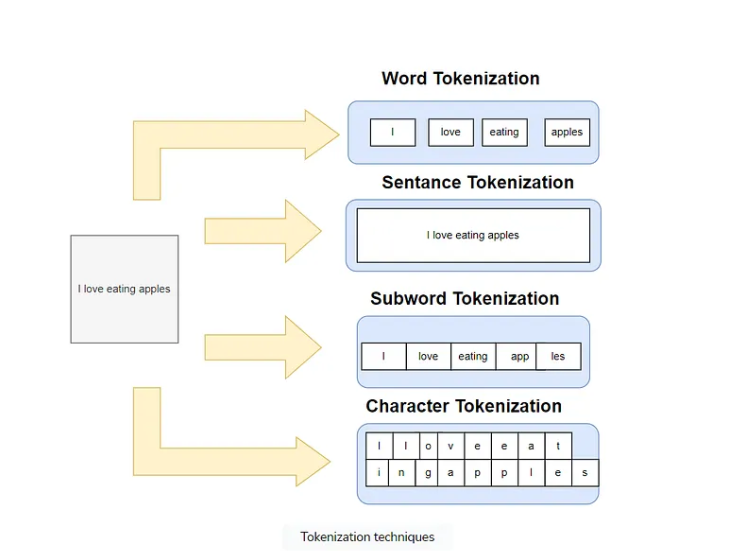

In [28]:
import nltk
from nltk.tokenize import word_tokenize

text = "In this article, we are learning word tokenization using NLTK."

tokens = word_tokenize(text)
print(tokens)

['In', 'this', 'article', ',', 'we', 'are', 'learning', 'word', 'tokenization', 'using', 'NLTK', '.']


In [34]:
!pip install nltk
nltk.download('punkt')
nltk.download('punkt_tab')


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\yogeshkannah\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\yogeshkannah\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\yogeshkannah\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [35]:
import nltk
from nltk.tokenize import sent_tokenize

text = """Hello! Sentence tokenization is essential for breaking down a text into its constituent sentences, which is a fundamental step in natural language processing. 
It allows you to work with sentences individually, making it easier to perform tasks like sentiment analysis, text summarization, and machine translation. 
NLTK provides a simple way to achieve sentence tokenization in Python."""

sentences = sent_tokenize(text)

for sentence in sentences:
    print(sentence)

Hello!
Sentence tokenization is essential for breaking down a text into its constituent sentences, which is a fundamental step in natural language processing.
It allows you to work with sentences individually, making it easier to perform tasks like sentiment analysis, text summarization, and machine translation.
NLTK provides a simple way to achieve sentence tokenization in Python.


In [36]:
text = "Hello World!"

characters = list(text)

print("Characters:", characters)

Characters: ['H', 'e', 'l', 'l', 'o', ' ', 'W', 'o', 'r', 'l', 'd', '!']


In [37]:
import nltk
from nltk.stem import WordNetLemmatizer 
import re
from nltk.corpus import stopwords

def preprocessing_text(text):
    lemmatizer = WordNetLemmatizer()
    emoji_pattern = r'^(?:[\u2700-\u27bf]|(?:\ud83c[\udde6-\uddff]){1,2}|(?:\ud83d[\udc00-\ude4f]){1,2}|[\ud800-\udbff][\udc00-\udfff]|[\u0021-\u002f\u003a-\u0040\u005b-\u0060\u007b-\u007e]|\u3299|\u3297|\u303d|\u3030|\u24c2|\ud83c[\udd70-\udd71]|\ud83c[\udd7e-\udd7f]|\ud83c\udd8e|\ud83c[\udd91-\udd9a]|\ud83c[\udde6-\uddff]|\ud83c[\ude01-\ude02]|\ud83c\ude1a|\ud83c\ude2f|\ud83c[\ude32-\ude3a]|\ud83c[\ude50-\ude51]|\u203c|\u2049|\u25aa|\u25ab|\u25b6|\u25c0|\u25fb|\u25fc|\u25fd|\u25fe|\u2600|\u2601|\u260e|\u2611|[^\u0000-\u007F])+$'
    
    text = text.split()
    text = [lemmatizer.lemmatize(word) for word in text if not word in set(stopwords.words('english'))]
    text = ' '.join(text)  
    text = re.sub(r'[0-9]+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(emoji_pattern, '', text)
    text= re.sub(r'\s+', ' ', text)
    text= text.lower().strip()
    
    return text

paragraph = """I am really disappointed this product. I would not use it again. It has really bad feature.
I love this product! It has some good features"""

sentences_list = nltk.sent_tokenize(paragraph)
 
corpus = [preprocessing_text(sentence) for sentence in sentences_list]

print(corpus)

['i really disappointed product', 'i would use again', 'it really bad feature', 'i love product', 'it good feature']


In [49]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()

X = vectorizer.fit_transform(corpus)

feature_names = vectorizer.get_feature_names_out()

X_array = X.toarray()
print("Unique Word List: \n", feature_names)
print("\nBag of Words Matrix: \n", X_array)

Unique Word List: 
 ['again' 'bad' 'disappointed' 'feature' 'good' 'it' 'love' 'product'
 'really' 'use' 'would']

Bag of Words Matrix: 
 [[0 0 1 0 0 0 0 1 1 0 0]
 [1 0 0 0 0 0 0 0 0 1 1]
 [0 1 0 1 0 1 0 0 1 0 0]
 [0 0 0 0 0 0 1 1 0 0 0]
 [0 0 0 1 1 1 0 0 0 0 0]]


In [46]:
import pandas as pd

df = pd.DataFrame(data=X_array, columns=feature_names, index=corpus)
df

,again,bad,disappointed,feature,good,it,love,product,really,use,would
i really disappointed product,0,0,1,0,0,0,0,1,1,0,0
i would use again,1,0,0,0,0,0,0,0,0,1,1
it really bad feature,0,1,0,1,0,1,0,0,1,0,0
i love product,0,0,0,0,0,0,1,1,0,0,0
it good feature,0,0,0,1,1,1,0,0,0,0,0


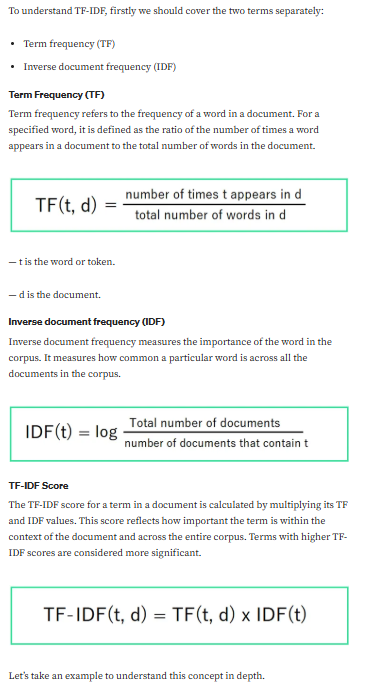

In [51]:
# Term Frequency & Inverse Document Frequency
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

tfidf_vectorizer = TfidfVectorizer()

tfidf_matrix = tfidf_vectorizer.fit_transform(corpus)

tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()

tfidf_array = tfidf_matrix.toarray()
df = pd.DataFrame(data=tfidf_array, columns=tfidf_feature_names, index=corpus)
df


,again,bad,disappointed,feature,good,it,love,product,really,use,would
i really disappointed product,0.00000,0.000000,0.659118,0.000000,0.000000,0.000000,0.000000,0.531772,0.531772,0.00000,0.00000
i would use again,0.57735,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.57735,0.57735
it really bad feature,0.00000,0.581951,0.000000,0.469515,0.000000,0.469515,0.000000,0.000000,0.469515,0.00000,0.00000
i love product,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.778283,0.627914,0.000000,0.00000,0.00000
it good feature,0.00000,0.000000,0.000000,0.531772,0.659118,0.531772,0.000000,0.000000,0.000000,0.00000,0.00000
